In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# 1. Load Dataset
df = pd.read_csv("final_ml_dataset.csv") 

df.shape

(144, 9)

In [3]:
df.head()

,lat,lon,rainfall,temp,humidity,dist_river,landuse,building_density,flood
0,30.25,77.95,73,307.95,10,594.047672,residential,0.0,0
1,30.25,77.97,31,307.98,10,756.136071,grass,0.0,0
2,30.25,77.99,0,307.98,10,155.599313,military,0.0,0
3,30.25,78.01,96,308.21,10,484.594668,military,0.0,1
4,30.25,78.03,27,308.49,10,319.512185,residential,0.0,0


In [4]:
df.describe()

,lat,lon,rainfall,temp,humidity,dist_river,building_density,flood
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,30.357361,78.040556,29.868056,305.647847,11.750000,578.893242,17.993056,0.298611
std,0.063190,0.064296,32.697436,3.086629,1.484182,487.367435,80.560753,0.459246
min,30.250000,77.950000,0.000000,297.130000,10.000000,4.115930,0.000000,0.000000
25%,30.310000,77.990000,0.000000,304.402500,11.000000,194.703636,0.000000,0.000000
50%,30.360000,78.030000,19.500000,306.855000,11.000000,459.062474,0.000000,0.000000
75%,30.410000,78.090000,57.000000,307.942500,12.000000,911.669302,1.000000,1.000000
max,30.450000,78.150000,100.000000,308.630000,17.000000,2263.185678,804.000000,1.000000


In [5]:
df.isnull().sum()

lat                 0
lon                 0
rainfall            0
temp                0
humidity            0
dist_river          0
landuse             0
building_density    0
flood               0
dtype: int64

In [6]:
# 2. Balance dataset 

from sklearn.utils import resample

df_majority = df[df.flood == 0]
df_minority = df[df.flood == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df = pd.concat([df_majority, df_minority_upsampled])

In [7]:
df.shape 

(202, 9)

In [8]:
df.head()

,lat,lon,rainfall,temp,humidity,dist_river,landuse,building_density,flood
0,30.25,77.95,73,307.95,10,594.047672,residential,0.0,0
1,30.25,77.97,31,307.98,10,756.136071,grass,0.0,0
2,30.25,77.99,0,307.98,10,155.599313,military,0.0,0
4,30.25,78.03,27,308.49,10,319.512185,residential,0.0,0
5,30.25,78.05,59,308.49,10,306.571727,industrial,0.0,0


In [9]:
df.tail()

,lat,lon,rainfall,temp,humidity,dist_river,landuse,building_density,flood
141,30.45,78.11,0,297.13,15,411.439306,residential,1.0,1
131,30.45,77.97,57,299.18,12,141.808169,forest,0.0,1
135,30.45,78.01,0,300.88,12,14.323227,forest,0.0,1
77,30.37,78.01,6,307.11,11,53.631325,forest,1.0,1
24,30.29,77.99,84,308.56,10,803.234380,forest,0.0,1


In [10]:
# 3. Preprocessing

le = LabelEncoder()
df["landuse"] = le.fit_transform(df["landuse"])

X = df.drop(columns=["flood"])
y = df["flood"]

In [11]:
# 3. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# 4. Models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", max_depth=5),
    "RandomForest": RandomForestClassifier(class_weight="balanced", max_depth=5, n_estimators=100),
    "GradientBoosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True, class_weight="balanced")
}

In [13]:
# 6. Train & Evaluate

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    }

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")


LogisticRegression
Accuracy: 0.4878
Precision: 0.4706
Recall: 0.4000
F1 Score: 0.4324

DecisionTree
Accuracy: 0.7317
Precision: 0.6667
Recall: 0.9000
F1 Score: 0.7660

RandomForest
Accuracy: 0.8293
Precision: 0.7600
Recall: 0.9500
F1 Score: 0.8444

GradientBoosting
Accuracy: 0.8293
Precision: 0.7826
Recall: 0.9000
F1 Score: 0.8372

SVM
Accuracy: 0.4878
Precision: 0.4706
Recall: 0.4000
F1 Score: 0.4324


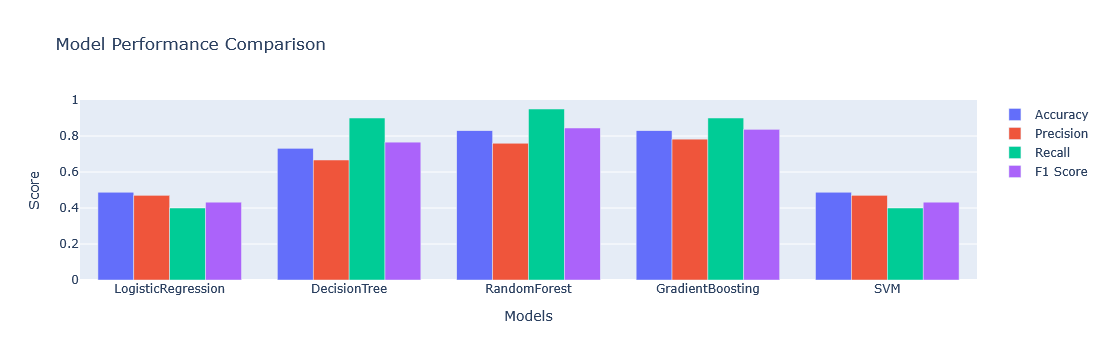

In [44]:
import plotly.graph_objects as go

models_list = list(results.keys())

accuracy = [results[m]["Accuracy"] for m in models_list]
precision = [results[m]["Precision"] for m in models_list]
recall = [results[m]["Recall"] for m in models_list]
f1 = [results[m]["F1 Score"] for m in models_list]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=models_list,
    y=accuracy,
    name="Accuracy",
))

fig.add_trace(go.Bar(
    x=models_list,
    y=precision,
    name="Precision",
))

fig.add_trace(go.Bar(
    x=models_list,
    y=recall,
    name="Recall",
))

fig.add_trace(go.Bar(
    x=models_list,
    y=f1,
    name="F1 Score",
))

fig.update_layout(
    title="Model Performance Comparison",
    xaxis_title="Models",
    yaxis_title="Score",
    barmode='group'
)

fig.show()

In [32]:
import plotly.graph_objects as go

models_list = list(results.keys())

accuracy = [results[m]["Accuracy"] for m in models_list]
precision = [results[m]["Precision"] for m in models_list]
recall = [results[m]["Recall"] for m in models_list]
f1 = [results[m]["F1 Score"] for m in models_list]


def create_bar_chart(y_values, title, y_label, color):
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=models_list,
        y=y_values,
        name=title,
        marker=dict(color=color),
        text=[round(v, 3) for v in y_values],  
        textposition='outside', 
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Models",
        height = 530, 
        width  = 1000,
        yaxis_title=y_label,
        uniformtext_minsize=8,
        uniformtext_mode='hide'
    )

    fig.show()

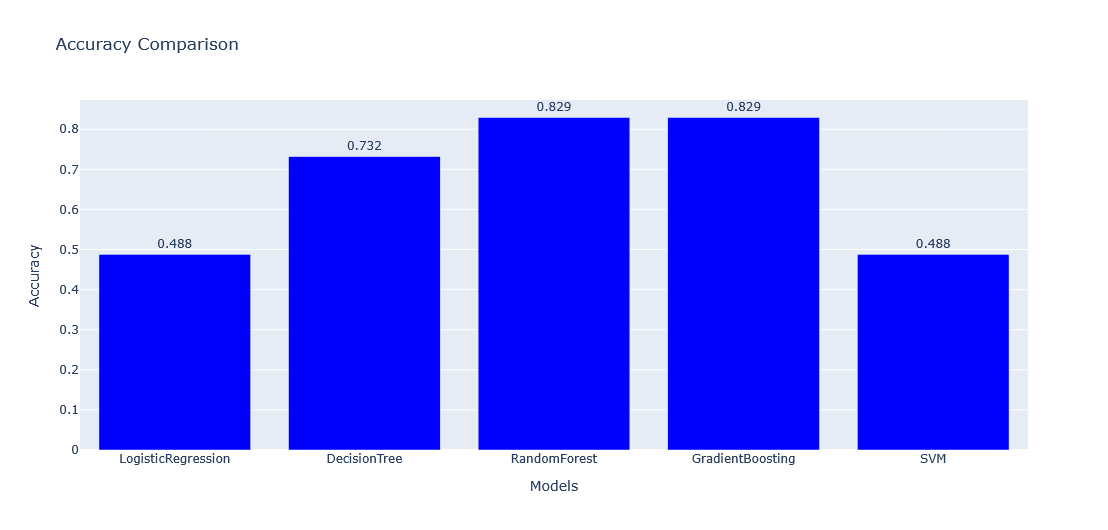

In [33]:
# Create 4 separate graphs
create_bar_chart(accuracy, "Accuracy Comparison", "Accuracy", "blue")

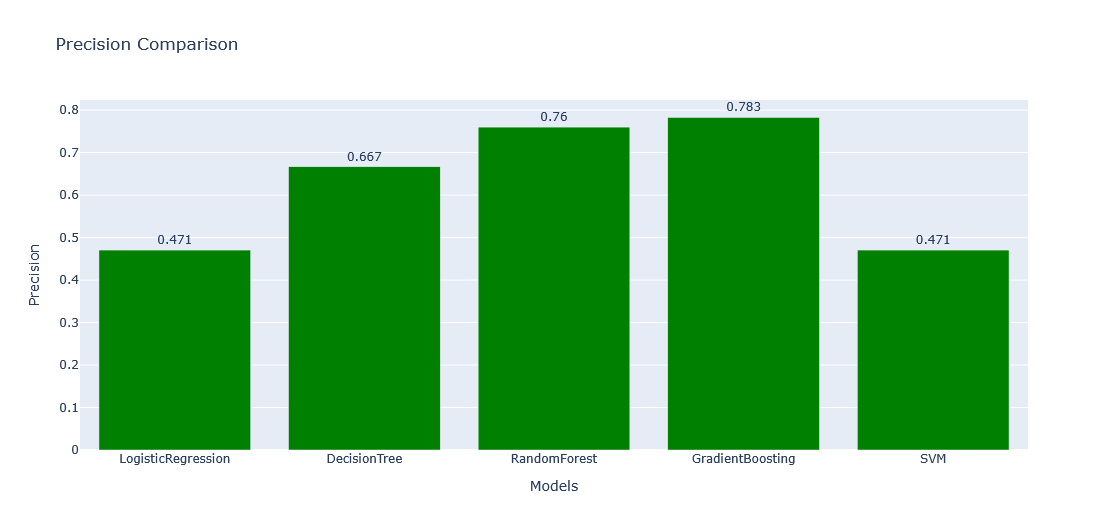

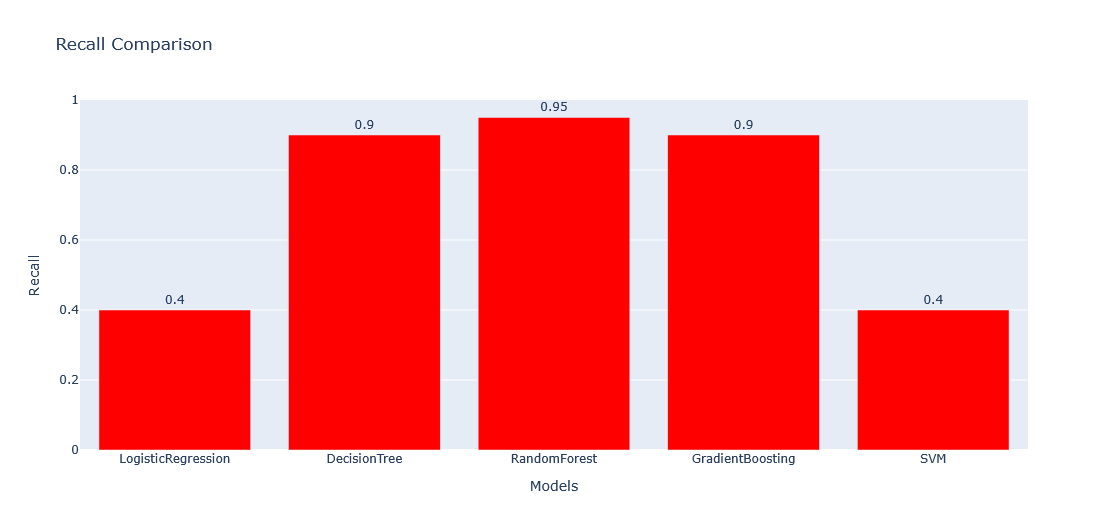

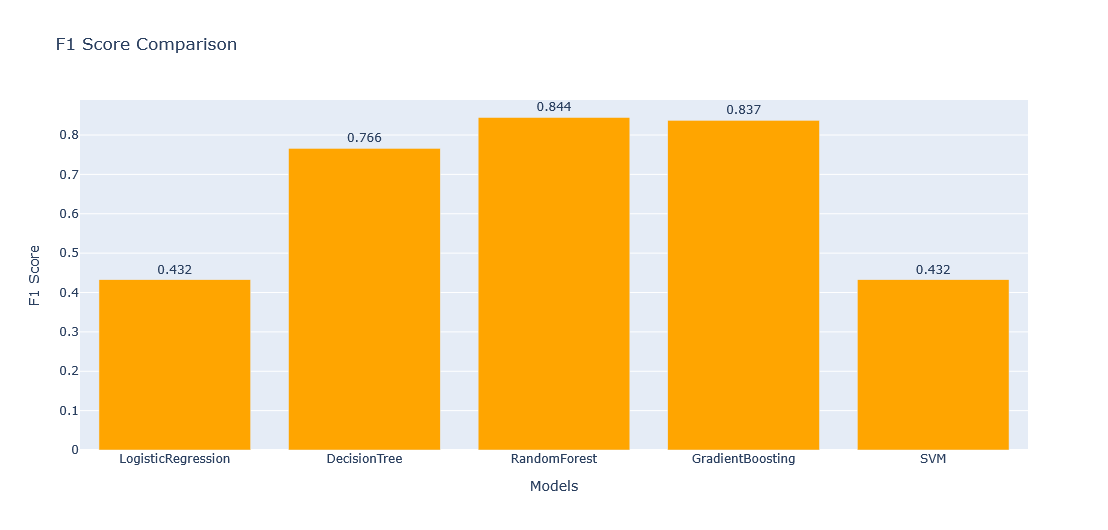

In [34]:
create_bar_chart(precision, "Precision Comparison", "Precision", "green")
create_bar_chart(recall, "Recall Comparison", "Recall", "red")
create_bar_chart(f1, "F1 Score Comparison", "F1 Score", "orange")

In [36]:
# 7. Select Best Model

best_model_name = max(results, key=lambda x: results[x]["Recall"])
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)



Best Model: RandomForest



Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.71      0.81        21
           1       0.76      0.95      0.84        20

    accuracy                           0.83        41
   macro avg       0.85      0.83      0.83        41
weighted avg       0.85      0.83      0.83        41



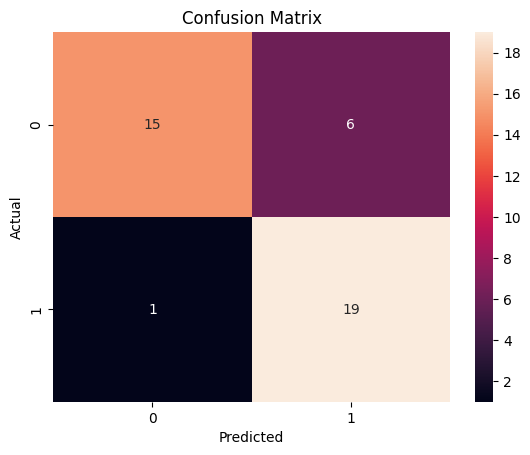

In [45]:
# 8. Confusion Matrix + Report

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")

print("\nClassification Report:\n")
print(classification_report(y_test, preds, zero_division=0))

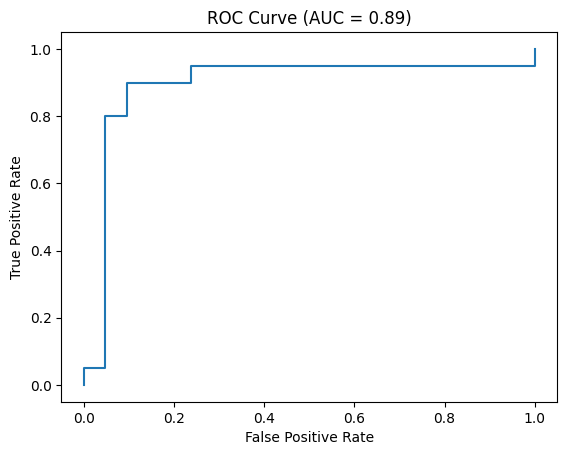

In [46]:
# 9. ROC Curve

from sklearn.metrics import roc_curve, auc

probs = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig("roc_curve.png")

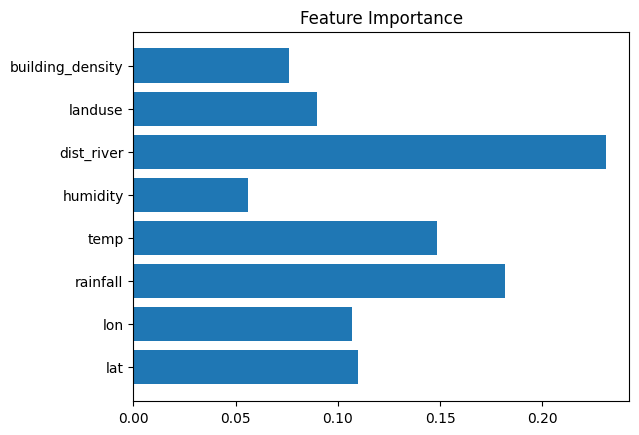

In [47]:
# 10. Feature Importance

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    features = X.columns

    plt.figure()
    plt.barh(features, importances)
    plt.title("Feature Importance")
    plt.savefig("feature_importance.png")

In [48]:
# 11. Save Model

import joblib

joblib.dump(best_model, "best_flood_model.pkl")
joblib.dump(le, "landuse_encoder.pkl")

print("\nModel saved successfully")


Model saved successfully
